In [1]:
from pathlib import Path
import pandas as pd
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import evaluate_finetuned_model, get_pretrained_model_url
from sklearn.metrics import classification_report
from demo_utils import plot_distribution

In [2]:
data_folder = Path.cwd().parent / "data/datasets"
composite_window = "month"
unique_id_column = "Field_ID"
target_name = 'Yield kg/H'

In [3]:
extractions = pd.read_parquet(data_folder/"ghana_maize_multiyear_extractions.parquet")
train_df, val_df, test_df = extractions[extractions["dataset"] == "train"], extractions[extractions["dataset"] == "val"], extractions[extractions["dataset"] == "test"]

#### Data investigation

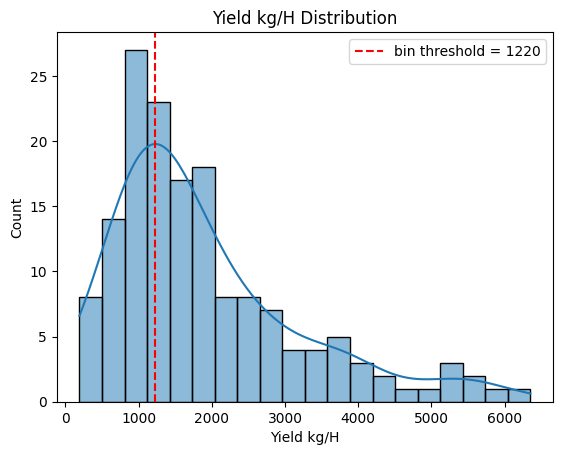

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
bin_th = 1220
sns.histplot(extractions[target_name], bins=20, kde=True)
plt.axvline(bin_th, color='red', linestyle='--', label=f"bin threshold = {str(bin_th)}")
plt.title('Yield kg/H Distribution')
plt.legend()
plt.show()

/data/users/Private/giorgia/git/GEOMaize/notebooks/demo_utils.py:85: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0, 2].set_xticklabels(['', '', 'Low', '', '', '', 'High', ''])


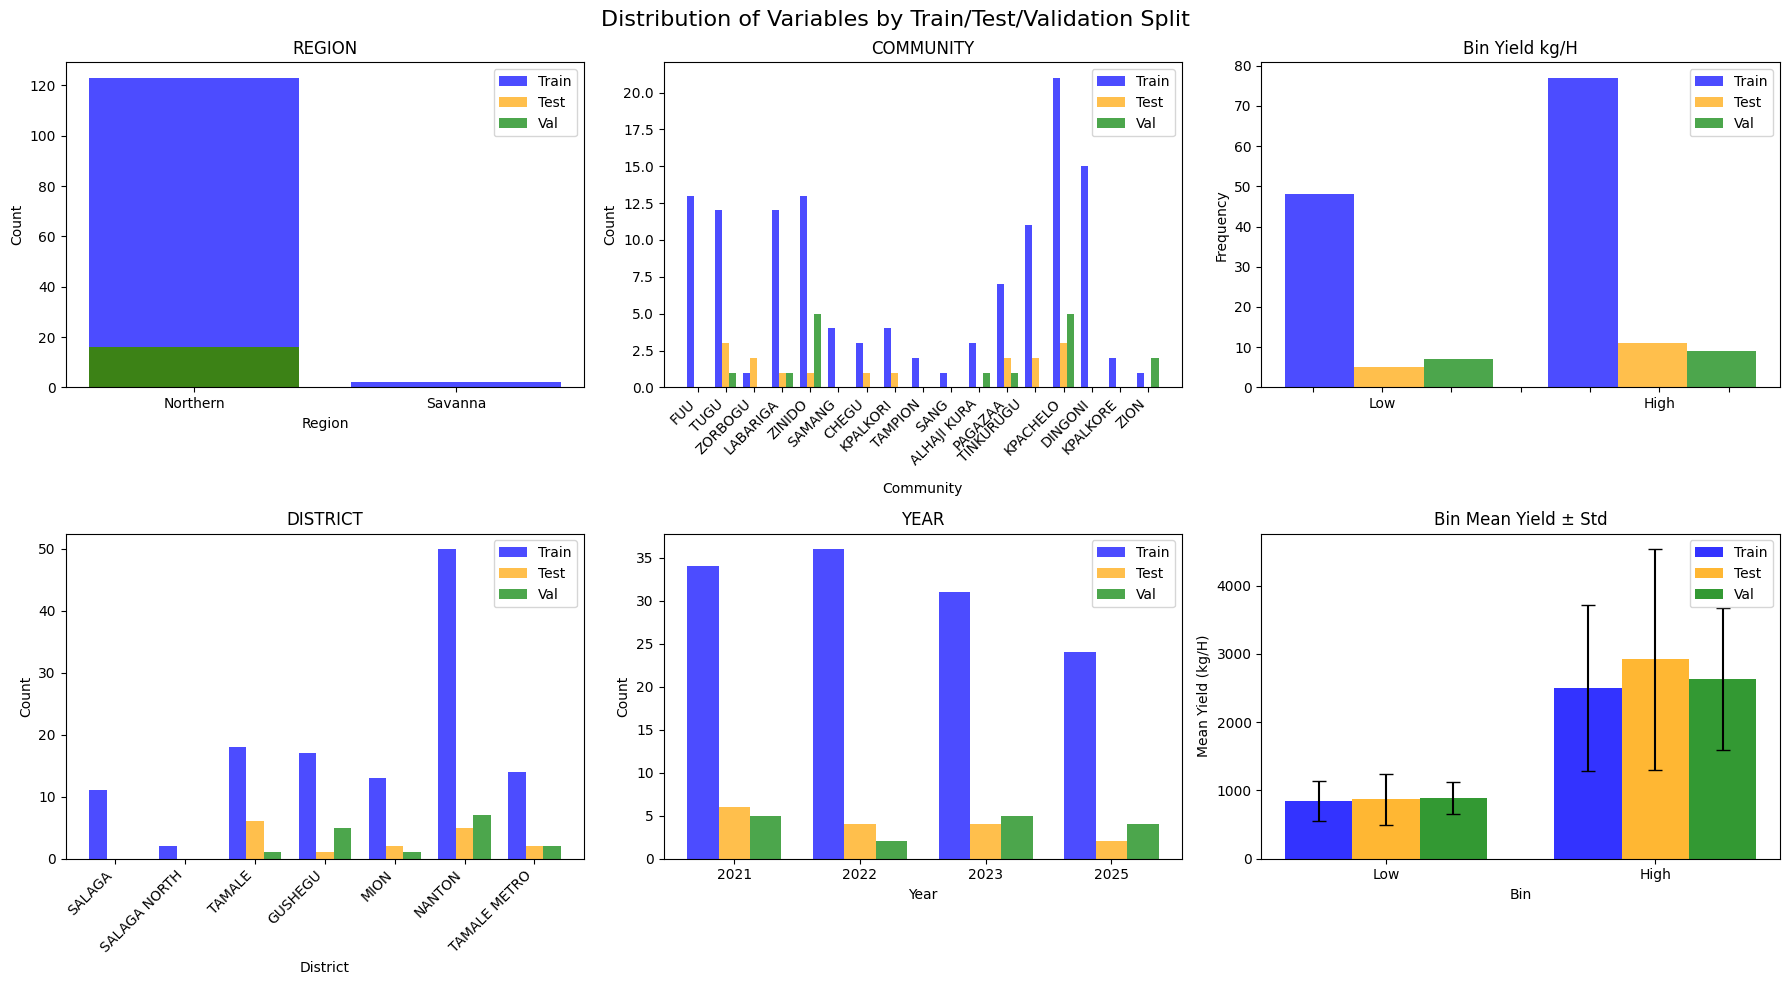

In [5]:
plot_distribution(train_df, test_df, val_df, 'bin')

##### Random Forest

In [ ]:
target_column = 'bin'

In [36]:
s2_cols = [col for col in extractions.columns if 'OPTICAL' in col]
s1_cols = [col for col in extractions.columns if 'SAR' in col]
dem_cols = [col for col in extractions.columns if 'DEM' in col]
meteo_cols = [col for col in extractions.columns if 'METEO' in col]
feature_columns = s2_cols + s1_cols + dem_cols + meteo_cols

In [37]:
X_train, y_train = train_df[feature_columns], train_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

In [38]:
import numpy as np 

X_train = X_train.replace(65535, np.nan)
X_val = X_val.replace(65535, np.nan)
X_test = X_test.replace(65535, np.nan)

In [39]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestClassifier(
        n_estimators=10,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        oob_score=True,
        warm_start=True
    ))
])

# Early stopping using validation set. this allows selecting the best n_estimators
best_val_score = -float('inf')
best_n_estimators = 10
patience = 5
no_improve = 0

for n_estimators in range(10, 101, 10):
    rf_pipe.named_steps['rf'].n_estimators = n_estimators
    rf_pipe.fit(X_train, y_train)
    val_score = rf_pipe.score(X_val, y_val)
    if val_score > best_val_score:
        best_val_score = val_score
        best_n_estimators = n_estimators
        no_improve = 0
    else:
        no_improve += 1
    if no_improve >= patience:
        break

# Refit with best n_estimators
rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestClassifier(
        n_estimators=best_n_estimators,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        oob_score=True,
        warm_start=True
    ))
])
rf_pipe.fit(X_train, y_train)

preds_train_rf = rf_pipe.predict(X_train)
preds_val_rf = rf_pipe.predict(X_val)
preds_test_rf = rf_pipe.predict(X_test)

##### Catboost 

In [40]:
from catboost import CatBoostClassifier

cat_clf = CatBoostClassifier(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='Logloss',  # Use 'Logloss' for binary classification
        verbose=100
)

cat_clf.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=20
)

preds_train_cb = cat_clf.predict(X_train) 
preds_val_cb = cat_clf.predict(X_val)
preds_test_cb = cat_clf.predict(X_test)


0:	learn: 0.6895918	test: 0.6906688	best: 0.6906688 (0)	total: 2.41ms	remaining: 1.2s
100:	learn: 0.4367590	test: 0.6115419	best: 0.6115419 (100)	total: 180ms	remaining: 711ms
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.6065610702
bestIteration = 122

Shrink model to first 123 iterations.


##### Presto

In [ ]:
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "binary"
target_name= "bin"

In [ ]:
train_ds = ScaleAgDataset(
    dataframe=train_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

In [25]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path(".").cwd().parent / "models"
experiment_name = f"presto-geomaize-ft-{composite_window}"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32 
num_workers = 0
max_epochs = 150  # Keep reasonable number of epochs
patience = 150  # More patience for convergence
learning_rate = 1e-3
# freeze_layers = ['encoder']

In [26]:
def finetune_presto(
    train_ds,
    val_ds,
    composite_window,
    num_outputs,
    experiment_name,
    model_output_dir,
    learning_rate=1e-3,
    max_epochs=100,
    batch_size=32,
    patience=10,
    num_workers=0,
):
    loss_fn = nn.BCEWithLogitsLoss()
    pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
    try:
        model = PretrainedPrestoWrapper(
            num_outputs=num_outputs,
            regression=False,
        )
        model = load_presto_weights(model, pretrained_model_path, strict=False)
    except:
        model = PretrainedPrestoWrapper(
            num_outputs=num_outputs,
            regression=False,
            pretrained_model_path=pretrained_model_path,
        )

    parameters = param_groups_lrd(model)
    optimizer = AdamW(parameters, lr=learning_rate)

    hyperparams = Hyperparams(
        max_epochs=max_epochs,
        batch_size=batch_size,
        patience=patience,
        num_workers=num_workers,
        lr=learning_rate,
    )

    scheduler = lr_scheduler.ConstantLR(optimizer, factor=1.0)
    # scheduler_plateau = lr_scheduler.ReduceLROnPlateau(optimizer, factor=drop_factor, min_lr=end_lr)
    train_dl = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )
    val_dl = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )

    finetuned_model = finetune.run_finetuning(
        model=model,
        train_dl=train_dl,
        val_dl=val_dl,
        experiment_name=experiment_name,
        output_dir=model_output_dir,
        loss_fn=loss_fn,
        optimizer=optimizer,
        scheduler=scheduler,
        hyperparams=hyperparams,
        setup_logging=False,  # Already setup logging
    )
    return finetuned_model

In [27]:
finetuned_model = finetune_presto(
    train_ds=train_ds,
    val_ds=val_ds,    
    composite_window=composite_window,
    num_outputs=num_outputs,
    experiment_name=experiment_name,
    model_output_dir=model_output_dir,
    learning_rate=learning_rate,
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers
)

2026-04-01 15:33:46.800 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/git/GEOMaize/models/presto-geomaize-ft-month


Finetuning:   0%|          | 0/150 [00:00<?, ?it/s]

Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-04-01 15:33:47.090 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/150: Epoch 1/150 | Train Loss: 0.7189 | Val Loss: 0.6903 | Best Loss: 0.6903 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

...

2026-04-01 15:34:26.280 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 148/150: Epoch 148/150 | Train Loss: 0.0723 | Val Loss: 1.3153 | Best Loss: 0.4261 (no improvement for 55 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-04-01 15:34:26.478 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 149/150: Epoch 149/150 | Train Loss: 0.0804 | Val Loss: 1.4063 | Best Loss: 0.4261 (no improvement for 56 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-04-01 15:34:26.730 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 150/150: Epoch 150/150 | Train Loss: 0.0941 | Val Loss: 1.3728 | Best Loss: 0.4261 (no improvement for 57 epochs)
2026-04-01 15:34:26.903 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


In [ ]:
# Get predictions for train and validation sets as well
train_metrics, train_preds_presto, train_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds_presto, val_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

test_metrics, test_preds_presto, test_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

if task_type == "binary":
    train_preds_presto = (train_preds_presto > 0.5).astype(int)
    val_preds_presto = (val_preds_presto > 0.5).astype(int)
    test_preds_presto = (test_preds_presto > 0.5).astype(int)

2026-04-01 15:36:27.129 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task
2026-04-01 15:36:27.285 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task
2026-04-01 15:36:27.312 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task


##### Presto + Catboost 

In [29]:
from scaleagdata_vito.presto.utils import get_encodings
from torch.utils.data import DataLoader

pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)

try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
        pretrained_model_path=pretrained_model_path,
    )

# model = finetuned_model #.copy()
all_encodings, all_targets = get_encodings(
    DataLoader(
        train_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ), 
    model
)

all_encodings_val, all_targets_val = get_encodings(
    DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model
)

all_encodings_test, all_targets_test = get_encodings(
    DataLoader(
        test_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model   
)

cat_enc_pipe = CatBoostClassifier(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='Logloss',  # Use 'Logloss' for binary classification
        verbose=100
    )

cat_enc_pipe.fit(
    all_encodings, all_targets,
    eval_set=(all_encodings_val, all_targets_val),
    early_stopping_rounds=20
    )

preds_test_presto_cb = cat_enc_pipe.predict(all_encodings_test)
preds_train_presto_cb = cat_enc_pipe.predict(all_encodings)
preds_val_presto_cb = cat_enc_pipe.predict(all_encodings_val)

0:	learn: 0.6884755	test: 0.6895476	best: 0.6895476 (0)	total: 6ms	remaining: 2.99s
100:	learn: 0.4306210	test: 0.6295913	best: 0.6286395 (99)	total: 371ms	remaining: 1.46s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.6252633935
bestIteration = 126

Shrink model to first 127 iterations.


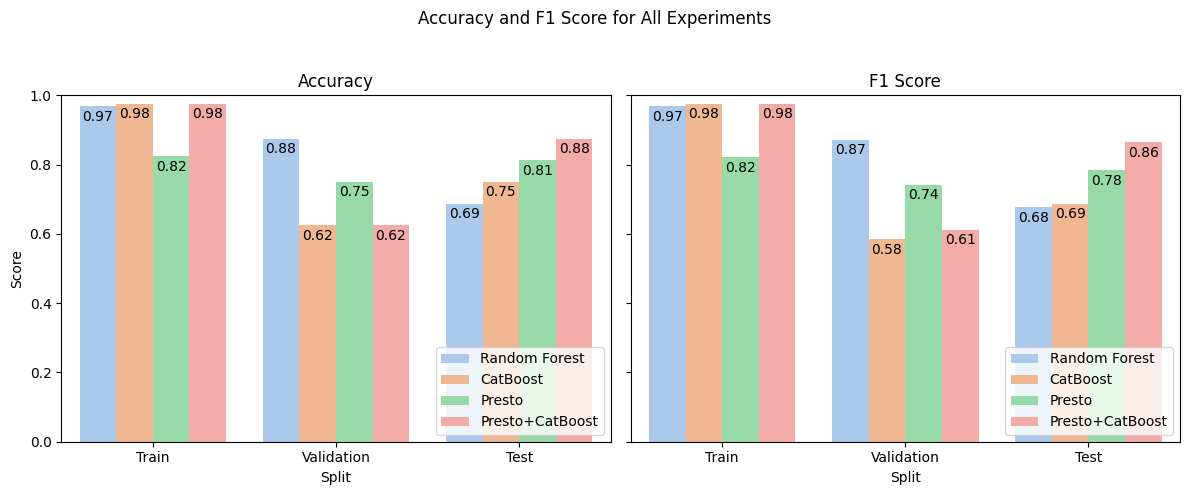

In [32]:
from sklearn.metrics import accuracy_score, f1_score

# Prepare predictions and labels for each experiment
experiments = {
    "Random Forest": (preds_train_rf, preds_val_rf, preds_test_rf),
    "CatBoost": (preds_train_cb, preds_val_cb, preds_test_cb),
    "Presto": (train_preds_presto, val_preds_presto, test_preds_presto),
    "Presto+CatBoost": (preds_train_presto_cb, preds_val_presto_cb, preds_test_presto_cb),
}

splits = [("Train", y_train), ("Validation", y_val), ("Test", y_test)]

metrics = []
for exp_name, (train_pred, val_pred, test_pred) in experiments.items():
    preds = [train_pred, val_pred, test_pred]
    for (split_name, y_true), y_pred in zip(splits, preds):
        # If predictions are torch tensors, convert to numpy
        if hasattr(y_pred, "detach"):
            y_pred = y_pred.detach().cpu().numpy()
        if hasattr(y_true, "values"):
            y_true = y_true.values
        # For Presto, predictions may be bool, convert to int
        y_pred = y_pred.astype(int)
        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        metrics.append({
            "Experiment": exp_name,
            "Split": split_name,
            "Accuracy": acc,
            "F1 Score": f1_macro
        })

metrics_df = pd.DataFrame(metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for i, metric in enumerate(["Accuracy", "F1 Score"]):
    ax = axes[i]
    sns.barplot(
        data=metrics_df,
        x="Split",
        y=metric,
        hue="Experiment",
        ax=ax,
        palette="pastel"
    )
    ax.set_ylim(0, 1)
    ax.set_title(metric)
    ax.set_ylabel("Score")
    ax.legend(loc="lower right")
    # Add numbers on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(f"{height:.2f}", 
                        (p.get_x() + p.get_width() / 2., height - 0.05), 
                        ha='center', va='bottom', fontsize=10, color='black', rotation=0)

plt.suptitle("Accuracy and F1 Score for All Experiments")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

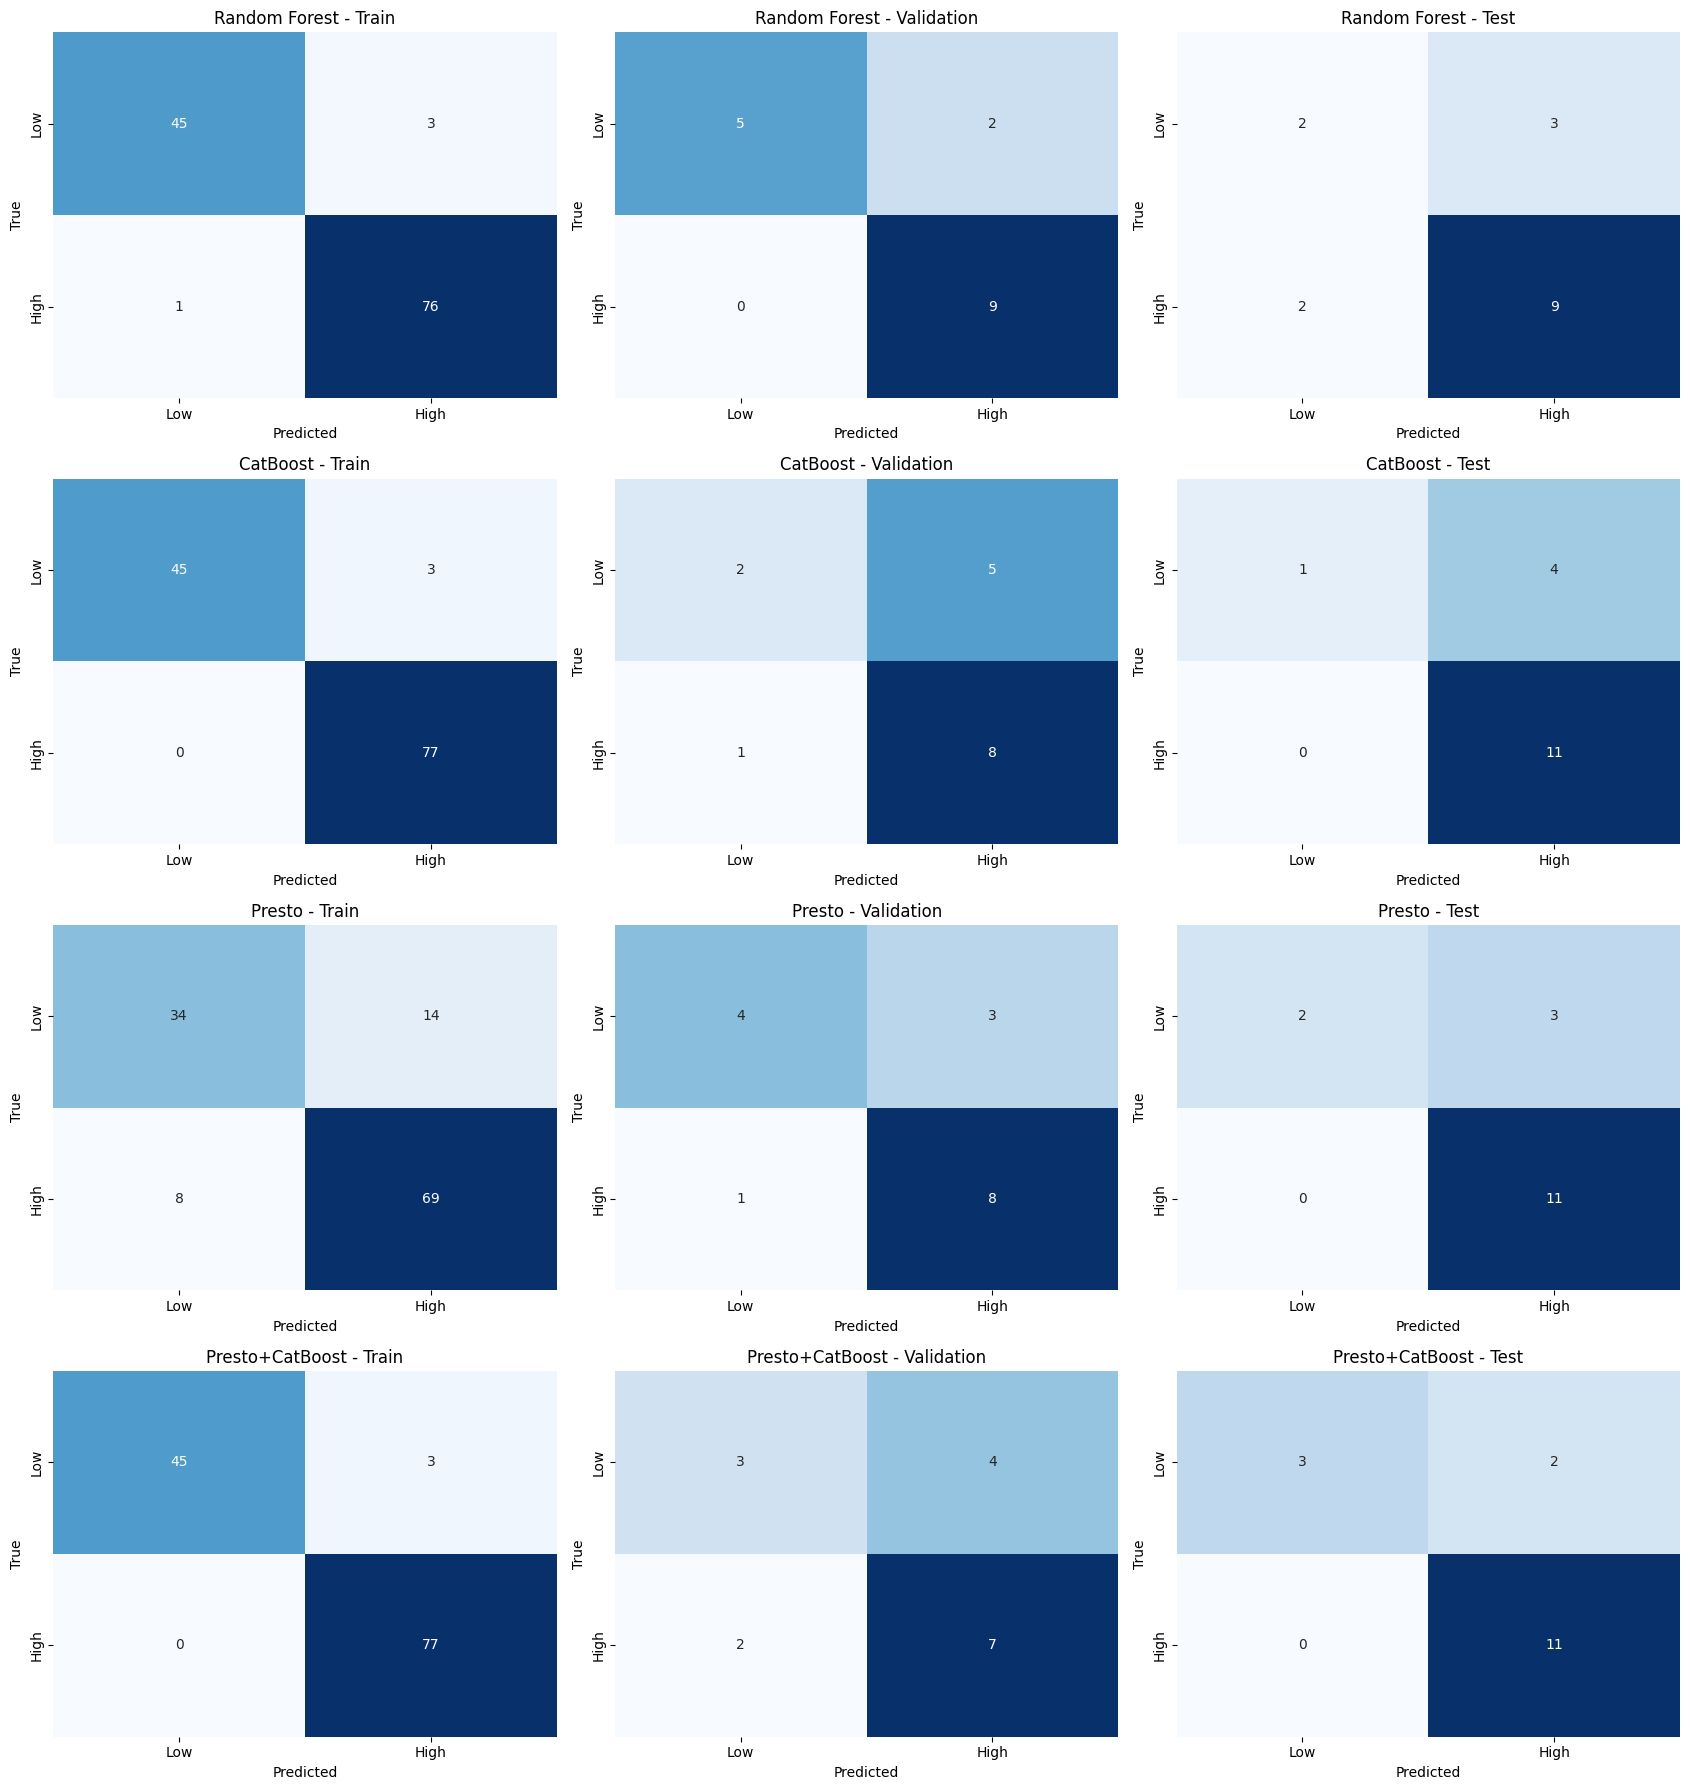

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare predictions and true labels for each model and split
model_names = ["Random Forest", "CatBoost", "Presto", "Presto+CatBoost"]
split_names = ["Train", "Validation", "Test"]
model_preds = [
    [preds_train_rf, preds_val_rf, preds_test_rf],
    [preds_train_cb, preds_val_cb, preds_test_cb],
    [train_preds_presto.astype(int), val_preds_presto.astype(int), test_preds_presto.astype(int)],
    [preds_train_presto_cb, preds_val_presto_cb, preds_test_presto_cb],
]
model_trues = [
    [y_train.values, y_val.values, y_test.values],
    [y_train.values, y_val.values, y_test.values],
    [train_targets_presto, val_targets_presto, test_targets_presto],
    [train_targets_presto, val_targets_presto, test_targets_presto],
]

fig, axes = plt.subplots(4, 3, figsize=(17, 18))

for row, model_name in enumerate(model_names):
    for col, split_name in enumerate(split_names):
        y_true = model_trues[row][col]
        y_pred = model_preds[row][col]
        # Convert boolean to int if needed
        if y_pred.dtype == bool:
            y_pred = y_pred.astype(int)
        if y_true.dtype == bool:
            y_true = y_true.astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col], cbar=False,
                    xticklabels=["Low", "High"], yticklabels=["Low", "High"])
        axes[row, col].set_xlabel('Predicted')
        axes[row, col].set_ylabel('True')
        axes[row, col].set_title(f"{model_name} - {split_name}")

plt.tight_layout()
plt.show()


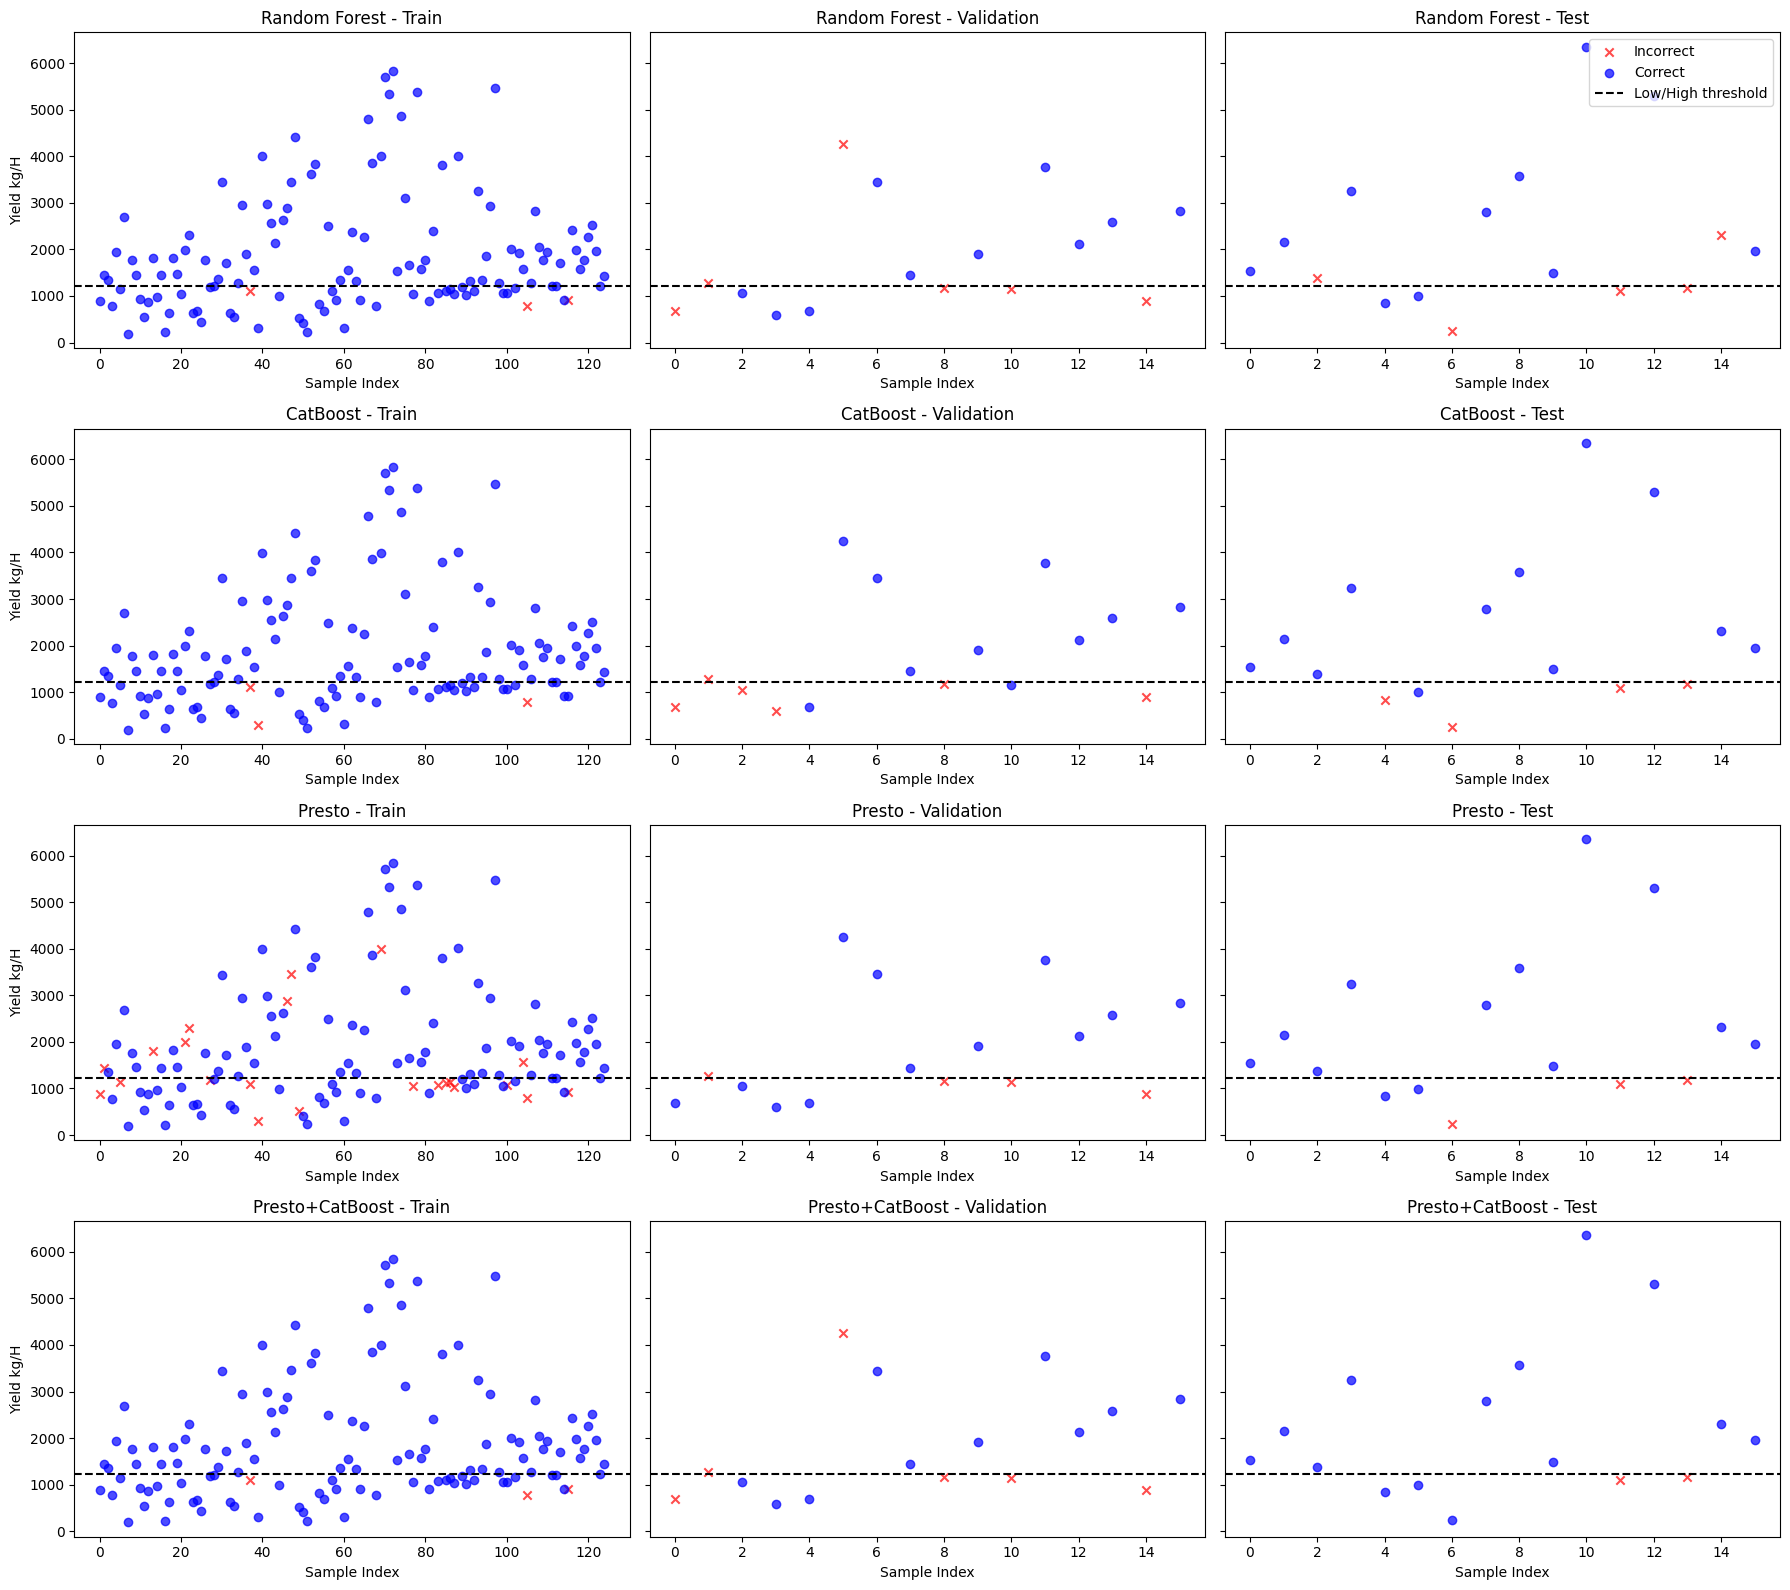

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for plotting
# Each entry: (Model Name, [y_true_train, y_true_val, y_true_test], [y_pred_train, y_pred_val, y_pred_test], [yields_train, yields_val, yields_test])
plot_data = [
    (
        "Random Forest",
        [y_train.values, y_val.values, y_test.values],
        [train_pred, val_pred, preds_test_rf],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
    (
        "CatBoost",
        [y_train.values, y_val.values, y_test.values],
        [preds_train_cb, preds_val_cb, preds_test_cb],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
    (
        "Presto",
        [train_targets_presto, val_targets_presto, test_targets_presto],
        [train_preds_presto.astype(int), val_preds_presto.astype(int), test_preds_presto.astype(int)],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
    (
        "Presto+CatBoost",
        [train_targets_presto, val_targets_presto, test_targets_presto],
        [preds_train_presto_cb, preds_val_presto_cb, preds_test_presto_cb],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
]

col_titles = ["Train", "Validation", "Test"]

fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=False, sharey=True)

for row, (model_name, y_trues, y_preds, yields) in enumerate(plot_data):
    for col in range(3):
        ax = axes[row, col]
        y_true = y_trues[col]
        y_pred = y_preds[col]
        yield_vals = yields[col]
        correct = (y_true == y_pred)
        # Plot correct in blue, incorrect in red
        ax.scatter(
            np.arange(len(yield_vals))[~correct], yield_vals[~correct], 
            c="red", label="Incorrect", alpha=0.7, marker="x"
        )
        ax.scatter(
            np.arange(len(yield_vals))[correct], yield_vals[correct], 
            c="blue", label="Correct", alpha=0.7, marker="o"
        )
        # Draw the bin threshold line and always show its label in the legend
        ax.axhline(bin_th, color="black", linestyle="--", label="Low/High threshold")
        ax.set_title(f"{model_name} - {col_titles[col]}")
        ax.set_xlabel("Sample Index")
        if col == 0:
            ax.set_ylabel("Yield kg/H")
        if row == 0 and col == 2:
            ax.legend(loc="upper right")

plt.tight_layout()
plt.show()